# Results reproduction consistency check

We load the (re)computed metrics (partitura use only) and compare to the reference numbers (mixture of partitura and pretty_midi use)

In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

---

## IR metrics

In [2]:
path_results_ir = '../results/IRMs' # results re-computed with latest partitura re-factored code
path_results_ir_ref = '../results_ref/IRMs' # exact reference results as reported in the paper

df_genre_ir = pd.read_csv(f'{path_results_ir}/1_genre_all.csv')
df_random_ir = pd.read_csv(f'{path_results_ir}/2_random_all.csv')
df_maetest_ir = pd.read_csv(f'{path_results_ir}/3_maetest_all.csv')

df_genre_ir_ref = pd.read_csv(f'{path_results_ir_ref}/1_genre_all.csv')
df_random_ir_ref = pd.read_csv(f'{path_results_ir_ref}/2_random_all.csv')
df_maetest_ir_ref = pd.read_csv(f'{path_results_ir_ref}/3_maetest_all.csv')

In [3]:
# column reordering after concat
ir_cols = ['model', 'midiset', 'audioset', 'genre', 'polyphony', 'dynamics', 'piece_id'] + list(df_genre_ir.columns[5:])

df_ir_all_new = pd.concat([df_genre_ir, df_random_ir, df_maetest_ir], ignore_index=True, sort=False)[ir_cols]
df_ir_all_ref = pd.concat([df_genre_ir_ref, df_random_ir_ref, df_maetest_ir_ref], ignore_index=True, sort=False)[ir_cols]
df_ir_all_diff = df_ir_all_new[ir_cols[7:]] - df_ir_all_ref[ir_cols[7:]]
df_ir_all_diff_annot = pd.concat((df_ir_all_new[ir_cols[:7]], df_ir_all_diff), axis=1)
df_ir_all_diff_annot

,model,midiset,audioset,genre,polyphony,dynamics,piece_id,p_frame,r_frame,f_frame,...,f_note_on,p_note_on_off,r_note_on_off,f_note_on_off,p_note_on_vel,r_note_on_vel,f_note_on_vel,p_note_on_off_vel,r_note_on_off_vel,f_note_on_off_vel
0,OaF,genre,disklavier,Blues,NaN,NaN,Blues_01,-0.000553,0.003570,0.001737,...,0.000000,-0.001415,-0.001313,-0.001362,0.000000,0.000000,0.000000,-0.000354,-0.000328,-0.000340
1,OaF,genre,disklavier,Blues,NaN,NaN,Blues_02,-0.000515,0.000640,0.000215,...,0.000000,-0.000759,-0.000873,-0.000812,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,OaF,genre,disklavier,Blues,NaN,NaN,Blues_03,0.014998,0.000127,0.006419,...,0.000000,-0.000714,-0.000710,-0.000712,0.000000,0.000000,0.000000,-0.005000,-0.004968,-0.004984
3,OaF,genre,disklavier,Blues,NaN,NaN,Blues_04,-0.001003,0.002102,0.000736,...,0.000000,-0.000696,-0.000661,-0.000678,0.000000,0.000000,0.000000,-0.000348,-0.000330,-0.000339
4,OaF,genre,disklavier,Blues,NaN,NaN,Blues_05,0.000517,0.003250,0.002007,...,0.000000,0.000339,0.000336,0.000337,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1055,Edwards,maetest,disklavier,NaN,NaN,NaN,MunA12M,-0.005430,0.039969,0.023130,...,0.000000,0.011798,0.011552,0.011674,0.000000,0.000000,0.000000,0.011480,0.011239,0.011358
1056,Edwards,maetest,disklavier,NaN,NaN,NaN,Nikiforov14M,-0.001247,0.008623,0.004276,...,0.000000,0.009804,0.009615,0.009709,0.000000,0.000000,0.000000,0.008987,0.008814,0.008900
1057,Edwards,maetest,disklavier,NaN,NaN,NaN,WongWY08M,-0.004043,0.007977,0.002246,...,0.000226,0.000906,0.000904,0.000905,-0.000226,-0.000226,-0.000226,0.000679,0.000678,0.000679
1058,Edwards,maetest,disklavier,NaN,NaN,NaN,YeF11M,-0.003615,0.003865,0.000261,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000164,-0.000164,-0.000164


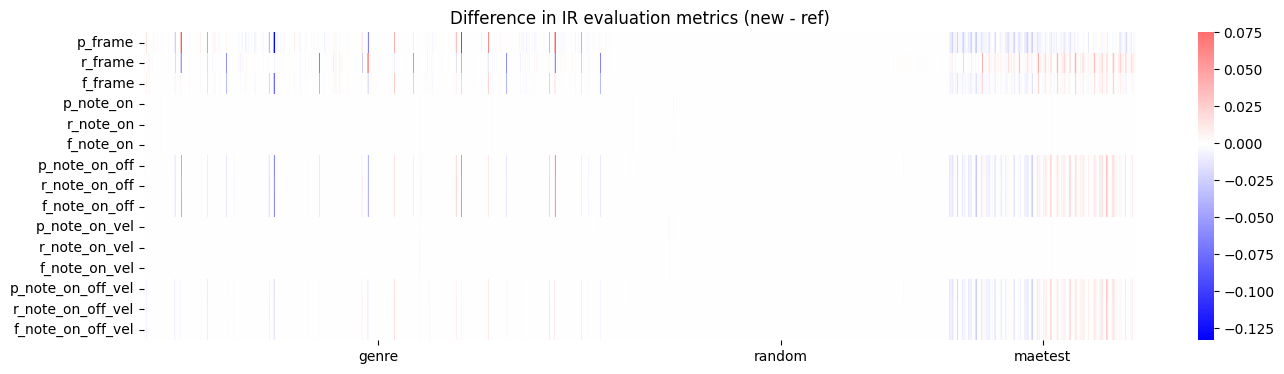

In [4]:
plt.figure(figsize=(16, 4))
sns.heatmap(df_ir_all_diff.T, cmap='bwr', center=0, vmin=df_ir_all_diff.min().min(), vmax=df_ir_all_diff.max().max());
xticks = []
last_midiset = None
for i, midiset in enumerate(df_ir_all_diff_annot['midiset']):
    if midiset != last_midiset:
        xticks.append((i, f'{midiset}'))
        last_midiset = midiset
plt.xticks(
    [(xticks[i][0] + xticks[i + 1][0]) / 2 for i in range(len(xticks) - 1)] + [(xticks[-1][0] + len(df_ir_all_diff_annot)) / 2],
    [x[1] for x in xticks],
    rotation=0);
plt.title('Difference in IR evaluation metrics (new - ref)');

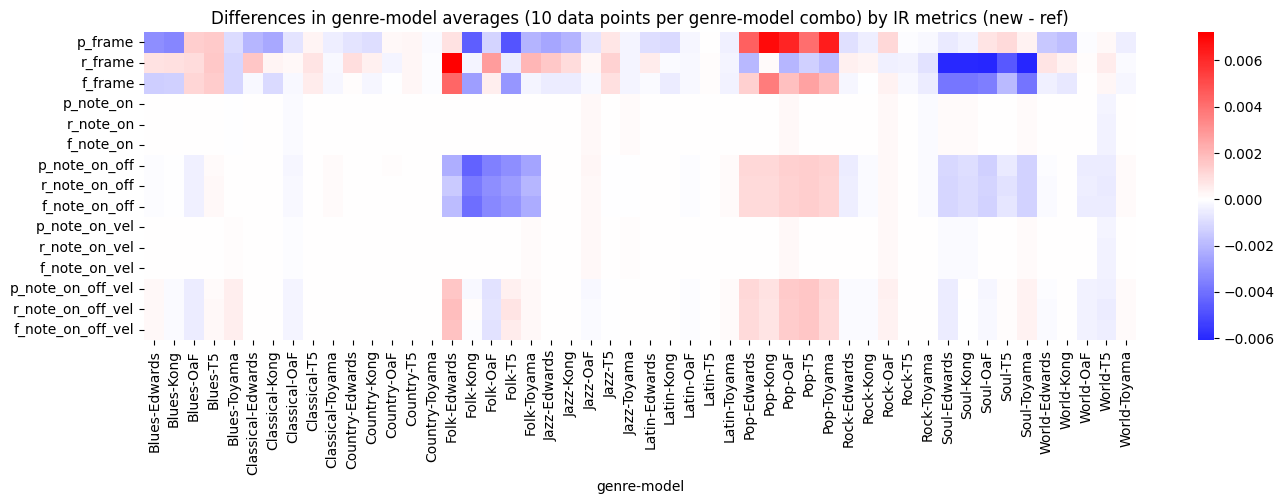

In [5]:
df_ir_genre_diff = df_genre_ir.groupby(['genre', 'model'])[ir_cols[7:]].mean() - df_genre_ir_ref.groupby(['genre', 'model'])[ir_cols[7:]].mean()

plt.figure(figsize=(16, 4))
sns.heatmap(df_ir_genre_diff.T, cmap='bwr', center=0, vmin=df_ir_genre_diff.min().min(), vmax=df_ir_genre_diff.max().max());
plt.title('Differences in genre-model averages (10 data points per genre-model combo) by IR metrics (new - ref)');

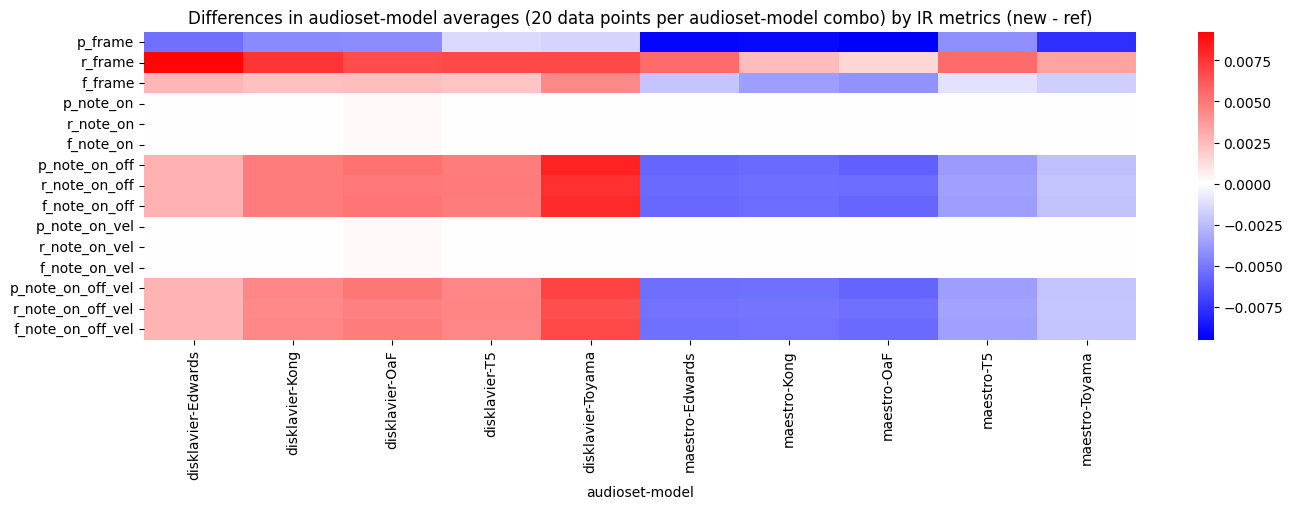

In [6]:
df_ir_maetest_diff = df_maetest_ir.groupby(['audioset', 'model'])[ir_cols[7:]].mean() - df_maetest_ir_ref.groupby(['audioset', 'model'])[ir_cols[7:]].mean()

plt.figure(figsize=(16, 4))
sns.heatmap(df_ir_maetest_diff.T, cmap='bwr', center=0, vmin=df_ir_maetest_diff.min().min(), vmax=df_ir_maetest_diff.max().max());
plt.title('Differences in audioset-model averages (20 data points per audioset-model combo) by IR metrics (new - ref)');

### Conclusion for the IR metrics

Most of the observed discrepancy between the original (paper reference) `pretty_midi`-based IR metrics computations, and the new default `partitura`-based computations, seems to be concentrated on the offset-aware metrics (`frame`, `on_off`, `on_off_vel`). We suspect that this is due to some leftover difference between how the two packages handle merging and splitting of note objects on temporal collisions caused by slight differences between how the sustain pedal information is processed by the two packages (we observe that there is no discrepancy on the Random subset which contains no sustain pedal usage, as opposed to the remaining subsets Genre and MAEtest).

---

## MI metrics

In [7]:
path_results_mi = '../results/MIMs'
path_results_mi_ref = '../results_ref/MIMs'

df_genre_mi = pd.read_csv(f'{path_results_mi}/1_genre_all.csv')
df_random_mi = pd.read_csv(f'{path_results_mi}/2_random_all.csv')
df_maetest_mi = pd.read_csv(f'{path_results_mi}/3_maetest_all.csv')

df_genre_mi_ref = pd.read_csv(f'{path_results_mi_ref}/1_genre_all.csv')
df_random_mi_ref = pd.read_csv(f'{path_results_mi_ref}/2_random_all.csv')
df_maetest_mi_ref = pd.read_csv(f'{path_results_mi_ref}/3_maetest_all.csv')

In [8]:
# column reordering after concat
mi_cols = ['model', 'midiset', 'audioset', 'genre', 'polyphony', 'dynamics', 'piece_id'] + list(df_genre_mi.columns[5:])

df_mi_all_new = pd.concat([df_genre_mi, df_random_mi, df_maetest_mi], ignore_index=True, sort=False)[mi_cols]
df_mi_all_ref = pd.concat([df_genre_mi_ref, df_random_mi_ref, df_maetest_mi_ref], ignore_index=True, sort=False)[mi_cols]
df_mi_all_diff = df_mi_all_new[mi_cols[7:]] - df_mi_all_ref[mi_cols[7:]]
df_mi_all_diff_annot = pd.concat((df_mi_all_new[mi_cols[:7]], df_mi_all_diff), axis=1)

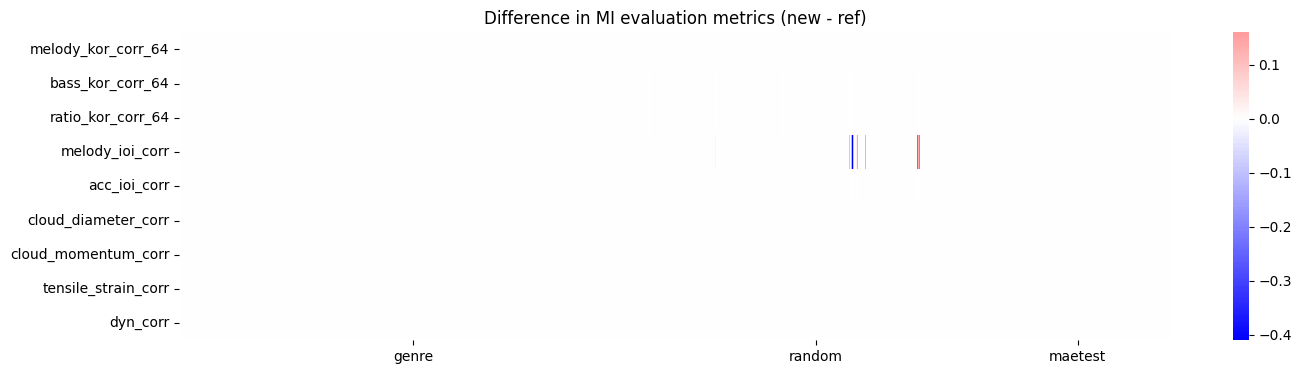

In [9]:
plt.figure(figsize=(16, 4))
sns.heatmap(df_mi_all_diff.T, cmap='bwr', center=0, vmin=df_mi_all_diff.min().min(), vmax=df_mi_all_diff.max().max());
xticks = []
last_midiset = None
for i, midiset in enumerate(df_mi_all_diff_annot['midiset']):
    if midiset != last_midiset:
        xticks.append((i, f'{midiset}'))
        last_midiset = midiset
plt.xticks(
    [(xticks[i][0] + xticks[i + 1][0]) / 2 for i in range(len(xticks) - 1)] + [(xticks[-1][0] + len(df_mi_all_diff_annot)) / 2],
    [x[1] for x in xticks],
    rotation=0);
plt.title('Difference in MI evaluation metrics (new - ref)');

In [10]:
df_mi_all_diff_annot[df_mi_all_diff_annot['melody_ioi_corr'].abs()>0]

,model,midiset,audioset,genre,polyphony,dynamics,piece_id,melody_kor_corr_64,bass_kor_corr_64,ratio_kor_corr_64,melody_ioi_corr,acc_ioi_corr,cloud_diameter_corr,cloud_momentum_corr,tensile_strain_corr,dyn_corr
573,Kong,random,disklavier,NaN,1.0,1.0,RANDOM_P01_D1,0.0,NaN,NaN,-0.014060,NaN,0.0,0.0,0.0,0.0
716,Toyama,random,disklavier,NaN,1.0,0.0,RANDOM_P01_D0,0.0,NaN,NaN,-0.085974,NaN,0.0,0.0,0.0,0.0
718,Toyama,random,disklavier,NaN,1.0,2.0,RANDOM_P01_D2,0.0,NaN,NaN,0.159753,NaN,0.0,0.0,0.0,0.0
719,Toyama,random,disklavier,NaN,2.0,0.0,RANDOM_P02_D0,0.0,0.0,0.0,-0.410463,NaN,0.0,0.0,0.0,0.0
720,Toyama,random,disklavier,NaN,2.0,1.0,RANDOM_P02_D1,0.0,0.0,0.0,-0.116021,NaN,0.0,0.0,0.0,0.0
723,Toyama,random,disklavier,NaN,3.0,1.0,RANDOM_P03_D1,0.0,0.0,0.0,0.022671,NaN,0.0,0.0,0.0,0.0
724,Toyama,random,disklavier,NaN,3.0,2.0,RANDOM_P03_D2,0.0,0.0,0.0,-0.118550,NaN,0.0,0.0,0.0,0.0
728,Toyama,random,disklavier,NaN,5.0,0.0,RANDOM_P05_D0,0.0,0.0,0.0,-0.154357,NaN,0.0,0.0,0.0,0.0
733,Toyama,random,disklavier,NaN,6.0,2.0,RANDOM_P06_D2,0.0,0.0,0.0,0.130269,NaN,0.0,0.0,0.0,0.0
788,Edwards,random,disklavier,NaN,1.0,0.0,RANDOM_P01_D0,0.0,NaN,NaN,-0.219188,NaN,0.0,0.0,0.0,0.0


### Conclusion for the MI metrics

Several updates related to low polyphony level processing between the versions of `partitura` used during paper production and the latest version 1.7.0 --> NaNs in certain MIMs + slight discrepancies in Melody IOI on the Random set. Since we don't report the MI metrics on the Random set in the paper anyway, as those don't carry much of a meaning, this is a non-issue.